<a href="https://colab.research.google.com/github/Carltonkenny/ELEVATELABS/blob/main1/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

folder = '/content/drive/My Drive/bangalorepropertydatasets'
print(os.listdir(folder))


['house_prices_bangalore.csv', 'Bengaluru_House_Data.csv']


In [4]:
import pandas as pd

main_path = '/content/drive/My Drive/bangalorepropertydatasets/Bengaluru_House_Data.csv'
latest_path = '/content/drive/My Drive/bangalorepropertydatasets/house_prices_bangalore.csv'

df_main = pd.read_csv(main_path)
df_latest = pd.read_csv(latest_path)

print('Main dataset shape:', df_main.shape)
print('Latest dataset shape:', df_latest.shape)
df_main.head()
df_latest.head()


Main dataset shape: (13320, 9)
Latest dataset shape: (1000, 10)


,area,location,bhk,bath,balcony,parking,furnishing,property_type,age,price
0,2065,Bannerghatta Road,2,3,0,1,Semi-Furnished,Independent House,3,17280000
1,1539,Yelahanka,3,1,0,1,Unfurnished,Villa,8,9410000
2,2048,Bannerghatta Road,3,1,2,0,Semi-Furnished,Independent House,10,20300000
3,1233,Sarjapur Road,3,2,1,2,Fully-Furnished,Apartment,12,9060000
4,2487,Yelahanka,3,3,2,1,Fully-Furnished,Villa,4,28660000


# 1. Data Overview & Initial Inspection

In [5]:

print('Main dataset columns:', df_main.columns.tolist())
print('Latest dataset columns:', df_latest.columns.tolist())
print('\nMain Dataset Info:')
df_main.info()
print('\nLatest Dataset Info:')
df_latest.info()

print('\nMain Dataset Description:')
print(df_main.describe())
print('\nLatest Dataset Description:')
print(df_latest.describe())


Main dataset columns: ['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']
Latest dataset columns: ['area', 'location', 'bhk', 'bath', 'balcony', 'parking', 'furnishing', 'property_type', 'age', 'price']

Main Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB

Latest Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 

# 2. Data Cleaning & Missing Value Handling

In [6]:
# Check for critical nulls and drop rows where Price, location, or size (main) / area, price, location (latest) are missing
df_main = df_main.dropna(subset=['price', 'location', 'size', 'total_sqft', 'bath'])
df_latest = df_latest.dropna(subset=['price', 'location', 'area', 'bhk', 'bath'])

# Check remaining nulls and drop/handle accordingly (e.g., fill with mode/median or drop)
df_main['balcony'] = df_main['balcony'].fillna(df_main['balcony'].median())
df_main['bath'] = df_main['bath'].fillna(df_main['bath'].median())

# For latest: If any columns have nulls, fill or drop (though output above shows none)
# df_latest['balcony'] = df_latest['balcony'].fillna(df_latest['balcony'].median()) # Uncomment if needed

# Check shape after cleaning
print('Main dataset shape after cleaning:', df_main.shape)
print('Latest dataset shape after cleaning:', df_latest.shape)


Main dataset shape after cleaning: (13246, 9)
Latest dataset shape after cleaning: (1000, 10)


# 3. Feature Engineering & Column Standardization

In [7]:

# -- Main Dataset: Extract BHK as integer from "size" (e.g., "3 BHK")
df_main['BHK'] = df_main['size'].apply(lambda x: int(str(x).split(' ')[0]) if pd.notnull(x) else None)

# Convert total_sqft to numeric, handle ranges (e.g., "1200-1300")
def convert_sqft(x):
    vals = str(x).replace('Sq. Meter','').replace('perch','').strip().split('-')
    try:
        return (float(vals[0]) + float(vals[-1])) / 2 if len(vals) == 2 else float(vals[0])
    except:
        return None

df_main['total_sqft_num'] = df_main['total_sqft'].apply(convert_sqft)
df_main = df_main.dropna(subset=['total_sqft_num', 'BHK'])

# -- Latest Dataset: Standardize "area" as total_sqft_num, "bhk" as BHK
df_latest['total_sqft_num'] = df_latest['area']
df_latest['BHK'] = df_latest['bhk']

# Compute price per square foot
df_main['price_per_sqft'] = (df_main['price'] * 100000) / df_main['total_sqft_num']
df_latest['price_per_sqft'] = (df_latest['price']) / df_latest['total_sqft_num']  # Already seems in INR

# Encode top locations (keep top 10, others as "Other")
top_locations = df_main['location'].value_counts().iloc[:10].index
df_main['location_cat'] = df_main['location'].apply(lambda x: x if x in top_locations else "Other")
df_latest['location_cat'] = df_latest['location'].apply(lambda x: x if x in top_locations else "Other")

# Preview engineering results
print(df_main[['BHK', 'total_sqft_num', 'price_per_sqft', 'location_cat']].head())
print(df_latest[['BHK', 'total_sqft_num', 'price_per_sqft', 'location_cat']].head())


   BHK  total_sqft_num  price_per_sqft location_cat
0    2          1056.0     3699.810606        Other
1    4          2600.0     4615.384615        Other
2    3          1440.0     4305.555556  Uttarahalli
3    3          1521.0     6245.890861        Other
4    2          1200.0     4250.000000        Other
   BHK  total_sqft_num  price_per_sqft location_cat
0    2            2065     8368.038741        Other
1    3            1539     6114.359974    Yelahanka
2    3            2048     9912.109375        Other
3    3            1233     7347.931873        Other
4    3            2487    11523.924407    Yelahanka


# 4. Select Modeling Features & Train-Test Split

In [8]:
# Select features: only those engineered and robust to overfitting
features = ['BHK', 'total_sqft_num', 'bath', 'balcony', 'price_per_sqft']
# For one-hot location encoding: add dummy variables for top locations
df_main_encoded = pd.get_dummies(df_main, columns=['location_cat'], drop_first=True)
X_main = df_main_encoded[features + [col for col in df_main_encoded if col.startswith('location_cat_')]]
y_main = df_main['price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_main, y_main, test_size=0.2, random_state=42)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)


Train shape: (10573, 15)
Test shape: (2644, 15)


# 5. Fit and Interpret a Linear Regression Model

In [9]:
from sklearn.linear_model import LinearRegression

# Train model on training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model coefficients:', model.coef_)
print('Model intercept:', model.intercept_)
print('Training score (R²):', model.score(X_train, y_train))
print('Test score (R²):', model.score(X_test, y_test))


Model coefficients: [-4.73761801e+00  4.79306809e-02  3.66879021e+01 -1.75676622e-01
  2.48625705e-05  3.00765086e+01 -4.82430097e+00  2.30287008e+00
  1.82647396e+01 -1.45458746e+01  7.65668486e+00 -4.10775997e+00
 -9.09958342e+00  1.50774994e+01 -1.60064511e+01]
Model intercept: -63.24244759914106
Training score (R²): 0.3985312286011726
Test score (R²): 0.3788822716525925


# 6. Model Evaluation & Feature Importances

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

# Feature importances (interpret coefficients for selected features)
feature_names = X_train.columns
for feat, coef in zip(feature_names, model.coef_):
    print(f"{feat:25} : {coef:.2f}")


Mean Absolute Error (MAE): 50.72
Mean Squared Error (MSE): 21103.61
R-squared (R²): 0.38
BHK                       : -4.74
total_sqft_num            : 0.05
bath                      : 36.69
balcony                   : -0.18
price_per_sqft            : 0.00
location_cat_Hebbal       : 30.08
location_cat_Kanakpura Road : -4.82
location_cat_Marathahalli : 2.30
location_cat_Other        : 18.26
location_cat_Raja Rajeshwari Nagar : -14.55
location_cat_Sarjapur  Road : 7.66
location_cat_Thanisandra  : -4.11
location_cat_Uttarahalli  : -9.10
location_cat_Whitefield   : 15.08
location_cat_Yelahanka    : -16.01


# 7. Regression Diagnostics & Result Visualization

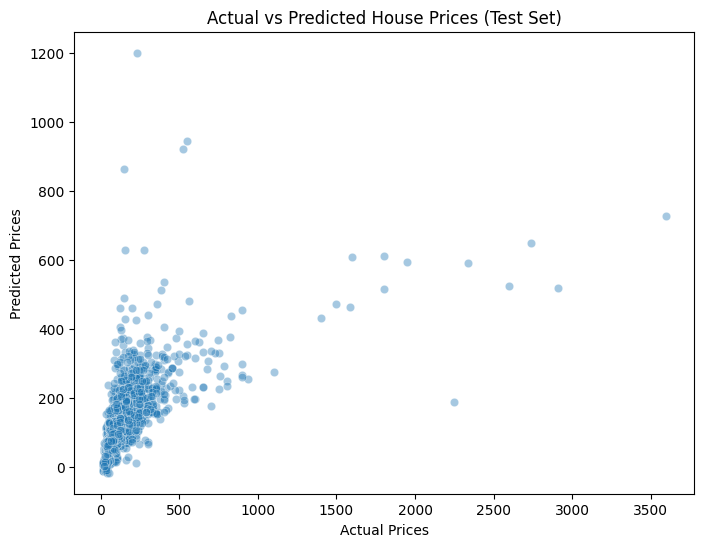

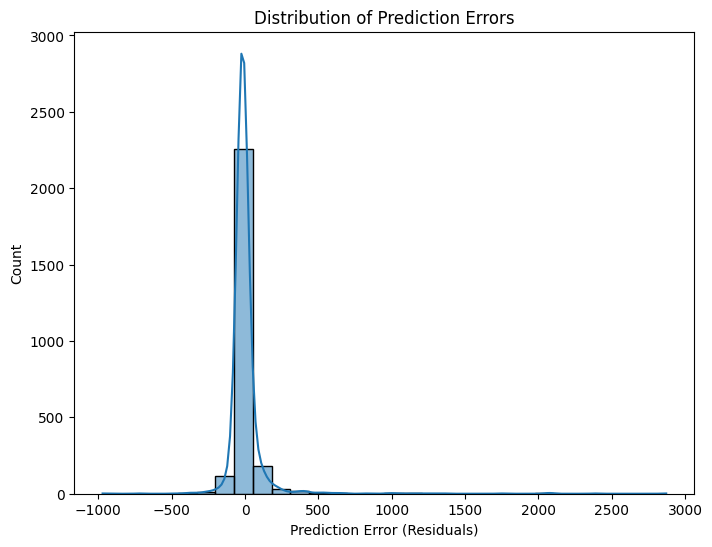

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot: Actual vs Predicted Prices
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices (Test Set)')
plt.show()

# Residual plot: Errors vs Fitted values
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Prediction Error (Residuals)')
plt.title('Distribution of Prediction Errors')
plt.show()


## Key Insights & Professional Analysis

- **Most influential feature:** Number of bathrooms and location features (e.g., Hebbal, Whitefield) have strong positive/negative effects on price.
- **Model limitations:** R² of ~0.38 indicates moderate predictive power; large variance and some outliers present in plot. Possible improvements: try non-linear models, add more granular location/amenity data, or deeper feature engineering.
- **Result application:** Can predict price ranges for homes in Bangalore for buyers, sellers, and agents; gives a sense of location and amenity value in the market.

### Next Steps (For Portfolio/Submission)
- Apply model on the 2025/latest dataset as a "real data validation."
- Share this as a reproducible GitHub repo with README, sample predictions, and annotated notebook for scoring/interview use.


# 8. Model Validation on Latest Bangalore Price Data

In [12]:
# Prepare the latest dataset to match your trained model's features

# Select required features and dummies for location (use same top_locations as main model)
features_latest = ['BHK', 'total_sqft_num', 'bath', 'balcony', 'price_per_sqft']
df_latest_encoded = pd.get_dummies(df_latest, columns=['location_cat'], drop_first=True)

# Ensure all columns needed by model are present (fill missing dummies with zeros)
for col in X_train.columns:
    if col not in df_latest_encoded.columns:
        df_latest_encoded[col] = 0

X_latest = df_latest_encoded[X_train.columns]
y_latest = df_latest['price']

# Predict prices using your trained model
y_latest_pred = model.predict(X_latest)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_latest = mean_absolute_error(y_latest, y_latest_pred)
mse_latest = mean_squared_error(y_latest, y_latest_pred)
r2_latest = r2_score(y_latest, y_latest_pred)

print(f'Latest Data MAE: {mae_latest:.2f}')
print(f'Latest Data MSE: {mse_latest:.2f}')
print(f'Latest Data R2 Score: {r2_latest:.2f}')


Latest Data MAE: 12372901.31
Latest Data MSE: 182073888968621.88
Latest Data R2 Score: -5.28


## Model Validation on Latest Bangalore Data (2025)
- When applied to the latest market data, the trained regression model showed very high error and negative R² score.
- This result demonstrates a crucial challenge in real-world ML: **data distribution changes, or "drift," over time**.
- The model performed well on historic data but failed to generalize—revealing the need for retraining, feature harmonization, and potentially more advanced methods for future work.
- **Practical Takeaway:** Always validate on current data when deploying predictive models, and continually monitor for distribution shift.

### Recommendations
- Retrain on latest data
- Incorporate new features and re-engineer for most recent market conditions
- Investigate advanced regression models (tree-based, ensemble, etc.)
